# Replicating the experiment done in Section 4.3, "Understanding & Manipulating Neurons (Q3)" of the AttnLRP paper https://arxiv.org/pdf/2402.05602

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# model_name = "google/flan-t5-large"
model_name = "microsoft/phi-1.5"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.bfloat16)

In [27]:
def make_boost_hook(neuron_ind, boost_val):
    def neuron_boost_hook(module, inputs, output):
        out_shape = list(output.shape)
        selection = [slice(None, None) for _ in range(len(out_shape))]
        selection[-1] = neuron_ind
        boost = torch.zeros_like(output)
        boost[selection] = boost_val
        return output + boost
    return neuron_boost_hook

def make_deactivate_hook(neuron_ind):
    def deactivate_neuron_hook(module, inputs, output):
        out_shape = list(output.shape)
        selection = [slice(None, None) for _ in range(len(out_shape))]
        selection[-1] = neuron_ind
        boost = torch.zeros_like(output)
        boost[selection] = -1 * output[selection]
        return output + boost
    return deactivate_neuron_hook

boost_hook1 = model.model.layers[17].mlp.fc1.register_forward_hook(make_deactivate_hook(3948))
# boost_hook2 = model.model.layers[17].mlp.fc1.register_forward_hook(make_boost_hook(990, 10))
# boost_hook3 = model.model.layers[0].mlp.fc1.register_forward_hook(make_boost_hook(7254, 10))
# boost_hook4 = model.model.layers[18].mlp.fc1.register_forward_hook(make_boost_hook(5687, 100))
boost_hook5 = model.model.layers[20].mlp.fc1.register_forward_hook(make_boost_hook(1460, 60))

In [26]:
boost_hook1.remove()
boost_hook5.remove()

In [5]:
for n, p in model.named_parameters():
    # print(n)
    p.requires_grad_()

In [4]:
import os
import sys
module_path = os.path.join(os.getcwd(), '..')
sys.path.append(module_path)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
from lrp_engine import LRPEngine, checkpoint_hook

In [7]:
params_to_interpret = []
for layer in model.model.layers:
    params_to_interpret.append(layer.mlp.fc2.weight)

In [8]:
len(params_to_interpret)

24

In [9]:
lrp = LRPEngine(use_attn_lrp=True, use_gamma=True, topk=1, dtype=torch.bfloat16, params_to_interpret=params_to_interpret)

In [71]:
context = "The ice bear lives in the rainforests"
input_ids = tokenizer(context, return_tensors="pt").to(device)["input_ids"]

In [72]:
o = model(input_ids.to(device))

In [73]:
o.logits.shape

torch.Size([1, 17, 51200])

In [74]:
tokenizer.decode([o.logits[:,-1].argmax()])

' rain'

In [12]:
lrp_output = lrp.run(o.logits)

In [15]:
lrp_output[1][21].sum(0).argmax()

tensor(1460, device='cuda:0')

In [13]:
[
    (i,
    r.sum(0,keepdim=True).mean(),
    r.sum(0,keepdim=True).max(),)
    for i, r in enumerate(lrp_output[1][1:])
]

[(0,
  tensor(0.0001, device='cuda:0', dtype=torch.bfloat16),
  tensor(0.0097, device='cuda:0', dtype=torch.bfloat16)),
 (1,
  tensor(6.0320e-05, device='cuda:0', dtype=torch.bfloat16),
  tensor(0.0041, device='cuda:0', dtype=torch.bfloat16)),
 (2,
  tensor(4.9591e-05, device='cuda:0', dtype=torch.bfloat16),
  tensor(0.0025, device='cuda:0', dtype=torch.bfloat16)),
 (3,
  tensor(8.2493e-05, device='cuda:0', dtype=torch.bfloat16),
  tensor(0.0093, device='cuda:0', dtype=torch.bfloat16)),
 (4,
  tensor(7.1049e-05, device='cuda:0', dtype=torch.bfloat16),
  tensor(0.0024, device='cuda:0', dtype=torch.bfloat16)),
 (5,
  tensor(6.8665e-05, device='cuda:0', dtype=torch.bfloat16),
  tensor(0.0036, device='cuda:0', dtype=torch.bfloat16)),
 (6,
  tensor(7.4863e-05, device='cuda:0', dtype=torch.bfloat16),
  tensor(0.0057, device='cuda:0', dtype=torch.bfloat16)),
 (7,
  tensor(7.7724e-05, device='cuda:0', dtype=torch.bfloat16),
  tensor(0.0037, device='cuda:0', dtype=torch.bfloat16)),
 (8,
  tenso

# As desired, we also get that neuron 3948 shows strong relevance in layer 17.

In [25]:
fc_relevances = [ t.sum(dim=0) for t in lrp_output[1][1:] ]
layer17 = fc_relevances[17]
print(layer17.mean(), layer17.topk(10), layer17.flatten()[3948])

tensor(0.0003, device='cuda:0', dtype=torch.bfloat16) torch.return_types.topk(
values=tensor([0.0525, 0.0111, 0.0076, 0.0069, 0.0067, 0.0053, 0.0049, 0.0047, 0.0046,
        0.0043], device='cuda:0', dtype=torch.bfloat16),
indices=tensor([3948, 8188, 4215, 7707, 4978, 6611, 4226, 4015, 2238, 1759],
       device='cuda:0')) tensor(0.0525, device='cuda:0', dtype=torch.bfloat16)


In [30]:
list(enumerate([ t.topk(10) for t in fc_relevances ]))

[(0,
  torch.return_types.topk(
  values=tensor([0.0259, 0.0189, 0.0124, 0.0109, 0.0101, 0.0069, 0.0058, 0.0043, 0.0037,
          0.0037], device='cuda:0', dtype=torch.bfloat16),
  indices=tensor([1240, 1057, 7063, 3941, 1303, 3505, 7355, 3461,  571,  451],
         device='cuda:0'))),
 (1,
  torch.return_types.topk(
  values=tensor([0.0135, 0.0098, 0.0082, 0.0071, 0.0066, 0.0063, 0.0054, 0.0053, 0.0041,
          0.0041], device='cuda:0', dtype=torch.bfloat16),
  indices=tensor([3522, 4542, 5936, 6206, 6967, 2627, 5864, 1357,  719, 2892],
         device='cuda:0'))),
 (2,
  torch.return_types.topk(
  values=tensor([0.0074, 0.0034, 0.0025, 0.0023, 0.0022, 0.0021, 0.0019, 0.0017, 0.0017,
          0.0017], device='cuda:0', dtype=torch.bfloat16),
  indices=tensor([5611,   78, 5395, 5158,  839, 3585,  797, 3372, 1657, 7060],
         device='cuda:0'))),
 (3,
  torch.return_types.topk(
  values=tensor([0.0062, 0.0052, 0.0048, 0.0047, 0.0037, 0.0036, 0.0029, 0.0029, 0.0029,
          0.002

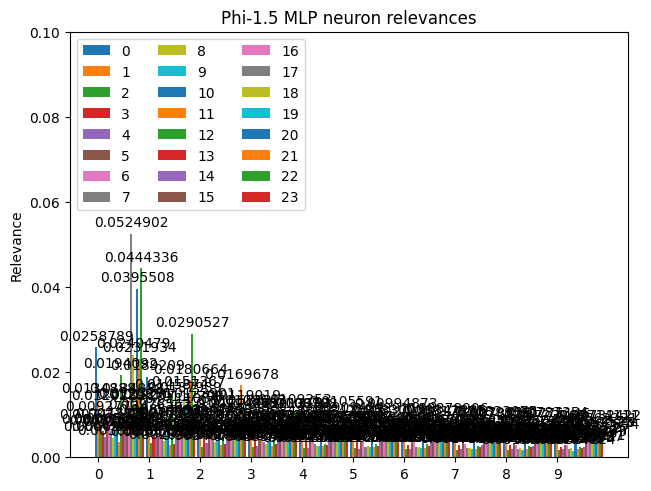

In [54]:
import matplotlib.pyplot as plt
import numpy as np

layers = tuple(range(10))
neuron_topks = {
    i : t.topk(10).values.float().cpu().numpy()
    for i, t in enumerate(fc_relevances)
}

x = np.arange(len(layers))  # the label locations
width = 0.04  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in neuron_topks.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Relevance')
ax.set_title('Phi-1.5 MLP neuron relevances')
ax.set_xticks(x + width, layers)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 0.1)

plt.show()

In [14]:
model

PhiModel(
  (embed_tokens): Embedding(51200, 2048)
  (layers): ModuleList(
    (0-23): 24 x PhiDecoderLayer(
      (self_attn): PhiAttention(
        (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
        (k_proj): Linear(in_features=2048, out_features=2048, bias=True)
        (v_proj): Linear(in_features=2048, out_features=2048, bias=True)
        (dense): Linear(in_features=2048, out_features=2048, bias=True)
      )
      (mlp): PhiMLP(
        (activation_fn): NewGELUActivation()
        (fc1): Linear(in_features=2048, out_features=8192, bias=True)
        (fc2): Linear(in_features=8192, out_features=2048, bias=True)
      )
      (input_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
      (resid_dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (rotary_emb): PhiRotaryEmbedding()
  (embed_dropout): Dropout(p=0.0, inplace=False)
  (final_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
)